<a href="https://colab.research.google.com/github/EliottDerven/Sentinel---Hackaton-Cap-gemini-Silicon-Days-API-Agents-inactive-/blob/main/R%C3%A9seauPneumonie1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# --- GÉNÉRATEURS AVEC NORMALISATION ---
# On ajoute de la "Data Augmentation" pour l'entraînement (train)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

# Pour la validation et le test, on se contente de normaliser (rescale)
test_val_datagen = ImageDataGenerator(rescale=1./255)

# --- CHARGEMENT DEPUIS TON DRIVE ---
train_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/archive/chest_xray/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = test_val_datagen.flow_from_directory(
    '/content/drive/MyDrive/archive/chest_xray/val',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_val_datagen.flow_from_directory(
    '/content/drive/MyDrive/archive/chest_xray/test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [ ]:
# --- CONSTRUCTION DU MODÈLE (CNN BINAIRE) ---
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Protection contre le sur-apprentissage
    layers.Dense(1, activation='sigmoid') # Sortie binaire
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# --- LANCEMENT DE L'APPRENTISSAGE ---
print("Lancement de l'entraînement sur GPU...")
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Lancement de l'entraînement sur GPU...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 577s 3s/step - accuracy: 0.7490 - loss: 0.5994 - val_accuracy: 0.7500 - val_loss: 0.6387
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 117s 717ms/step - accuracy: 0.9102 - loss: 0.2383 - val_accuracy: 0.8125 - val_loss: 0.7784
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 122s 745ms/step - accuracy: 0.9295 - loss: 0.1864 - val_accuracy: 0.8125 - val_loss: 0.6546
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 116s 711ms/step - accuracy: 0.9346 - loss: 0.1702 - val_accuracy: 0.7500 - val_loss: 1.0073
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 116s 713ms/step - accuracy: 0.9366 - loss: 0.1669 - val_accuracy: 0.7500 - val_loss: 0.6856
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 116s 714ms/step - accuracy: 0.9399 - loss: 0.1553 - val_accuracy: 0.7500 - val_loss: 0.9003
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 140s 705ms/step - accuracy: 0.9480 - loss: 0.1418 - val_accuracy: 0.8125 - val_loss: 0.3416
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 116s 711ms/step - accuracy: 0.9494 - lo

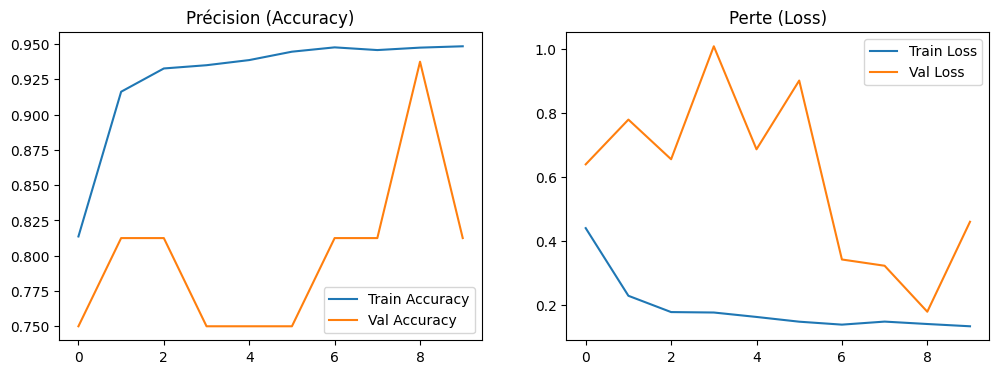

In [ ]:
# --- GRAPHIQUES DE PERFORMANCE ---
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Précision (Accuracy)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Perte (Loss)')
plt.legend()

plt.show()

In [ ]:
# 1. Évaluation globale sur le dossier Test
print("Calcul de la précision finale sur le dossier Test...")
test_results = model.evaluate(test_generator, verbose=1)

print("\n" + "="*30)
print(f"RÉSULTAT FINAL TEST")
print(f"Précision (Accuracy) : {test_results[1]*100:.2f}%")
print(f"Perte (Loss) : {test_results[0]:.4f}")
print("="*30)

Calcul de la précision finale sur le dossier Test...
20/20 ━━━━━━━━━━━━━━━━━━━━ 173s 9s/step - accuracy: 0.7259 - loss: 0.8083

RÉSULTAT FINAL TEST
Précision (Accuracy) : 84.29%
Perte (Loss) : 0.4821


In [ ]:
# Affiche l'architecture détaillée du réseau de neurones
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,507,269 (127.82 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,338,180 (85.21 MB)

In [ ]:
# Sauvegarde du cerveau de ton IA
model.save('modele_pneumonie_84pourcent.h5')

# Téléchargement sur ton PC
from google.colab import files
files.download('modele_pneumonie_84pourcent.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>